In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

### Задача 1. Базовая классификация на данных Iris

**Цель:** Применить три алгоритма к простому датасету и сравнить их базовую производительность.

### Инструкция:
1. Загрузите `load_iris`.
2. Разделите данные: 70% — обучающая выборка, 30% — тестовая выборка.
3. Обучите три модели:
   - **k-NN** (`k=3`)
   - **SVM** (`kernel='linear'`)
   - **Дерево решений** (по умолчанию)
4. **Важно:** Для k-NN и SVM примените `StandardScaler` к обучающим и тестовым данным.
5. Оцените **правильность** (`accuracy`) каждой модели на тесте.
6. Для дерева — визуализируйте его с помощью `plot_tree`.
7. Ответьте на вопрос, почему все три модели показывают почти 100% правильность на наборе ирисов?

In [10]:
# 1. Загрузка данных Iris
print("=== ЗАГРУЗКА ДАННЫХ IRIS ===")
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Размер данных: {X.shape}")
print(f"Классы: {target_names}")
print(f"Признаки: {feature_names}")
print(f"Распределение классов: {np.bincount(y)}")

=== ЗАГРУЗКА ДАННЫХ IRIS ===
Размер данных: (150, 4)
Классы: ['setosa' 'versicolor' 'virginica']
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Распределение классов: [50 50 50]


In [11]:
# 2. Разделение данных
print("\n=== РАЗДЕЛЕНИЕ ДАННЫХ ===")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train)}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test)}")


=== РАЗДЕЛЕНИЕ ДАННЫХ ===
Обучающая выборка: (105, 4)
Тестовая выборка: (45, 4)
Распределение классов в обучающей выборке: [35 35 35]
Распределение классов в тестовой выборке: [15 15 15]


In [12]:
# 3. Масштабирование данных для k-NN и SVM
print("\n=== МАСШТАБИРОВАНИЕ ДАННЫХ ===")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено для k-NN и SVM")
print(f"Исходные данные (первые 3 строки):")
print(X_train[:3])
print(f"Масштабированные данные (первые 3 строки):")
print(X_train_scaled[:3])


=== МАСШТАБИРОВАНИЕ ДАННЫХ ===
Масштабирование выполнено для k-NN и SVM
Исходные данные (первые 3 строки):
[[5.1 2.5 3.  1.1]
 [6.2 2.2 4.5 1.5]
 [5.1 3.8 1.5 0.3]]
Масштабированные данные (первые 3 строки):
[[-0.90045861 -1.22024754 -0.4419858  -0.13661044]
 [ 0.38036614 -1.87955796  0.40282929  0.38029394]
 [-0.90045861  1.63676428 -1.2868009  -1.17041921]]


In [14]:
# 4. Обучение моделей
print("\n=== ОБУЧЕНИЕ МОДЕЛЕЙ ===")

# k-NN (k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

# SVM (kernel='linear')
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

# Дерево решений (по умолчанию)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)  # Для дерева не нужно масштабирование
tree_pred = tree.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Результаты классификации:")
print(f"k-NN (k=3):     {knn_accuracy:.4f}")
print(f"SVM (linear):   {svm_accuracy:.4f}")
print(f"Decision Tree:  {tree_accuracy:.4f}")


=== ОБУЧЕНИЕ МОДЕЛЕЙ ===
Результаты классификации:
k-NN (k=3):     0.9111
SVM (linear):   0.9111
Decision Tree:  0.9333



=== ВИЗУАЛИЗАЦИЯ ДЕРЕВА РЕШЕНИЙ ===


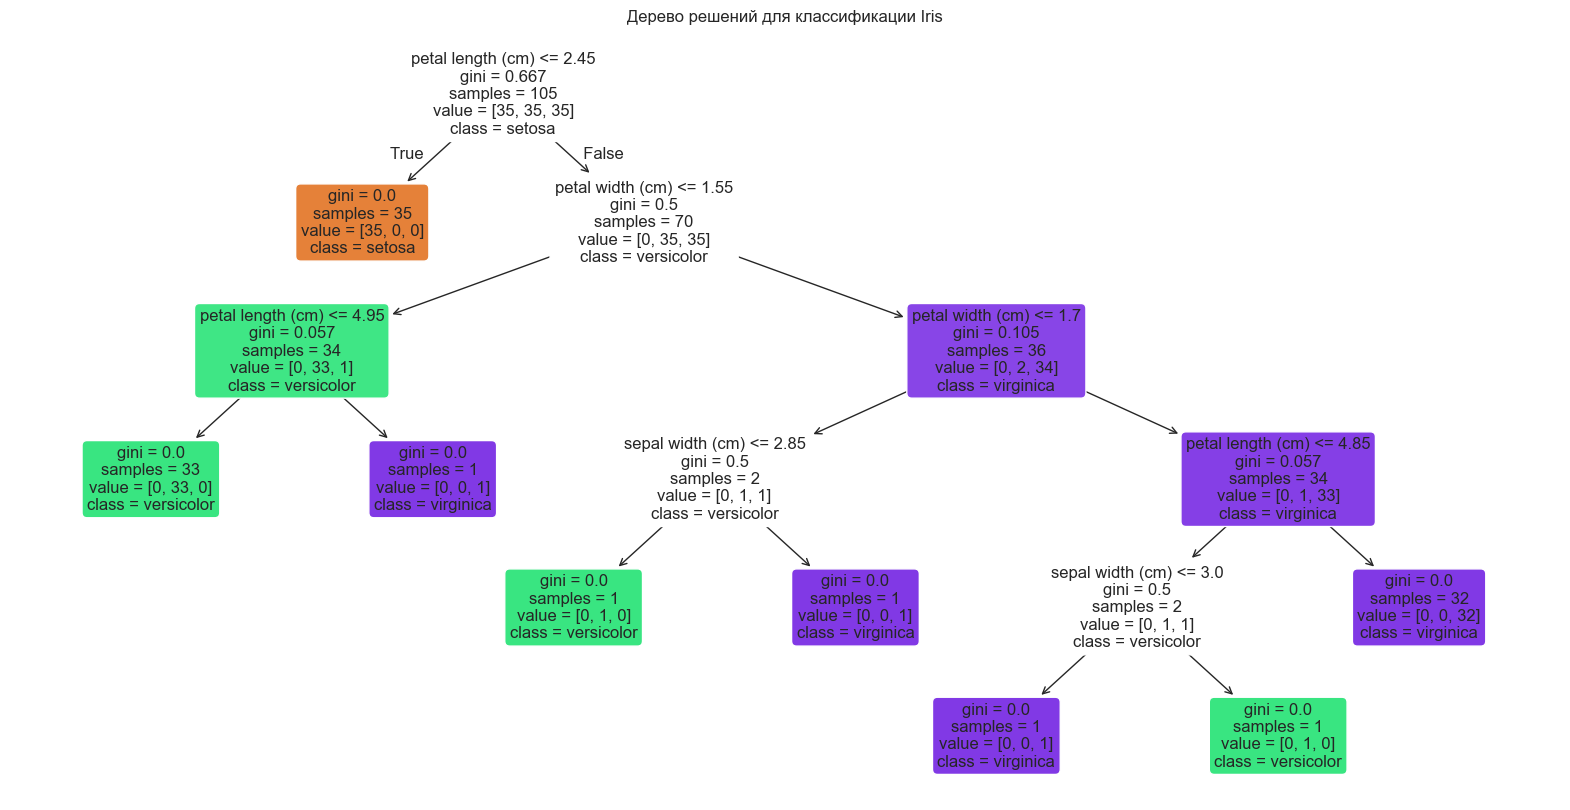

In [16]:
# 5. Визуализация дерева решений
print("\n=== ВИЗУАЛИЗАЦИЯ ДЕРЕВА РЕШЕНИЙ ===")

# Импортируем plot_tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree, 
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Дерево решений для классификации Iris')
plt.show()

### Задача 2. Влияние предобработки и гиперпараметров на данных Wine

**Цель:** Исследовать чувствительность моделей к масштабированию и настройке.

Инструкция:
1. Загрузите `load_wine`.
2. Разделите данные: 80% — обучающая выборка, 20% — тестовая выборка.
3. Выполните два эксперимента:
    1. SVM: с и без масштабирования
    2. Дерево: с ограничением глубины и без
4. Ответьте на вопрос, почему SVM сильно выигрывает от масштабирования, а дерево — нет?

In [19]:
# Загрузка и разделение данных Wine
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# A. SVM: с и без масштабирования
svm_no_scale = SVC(kernel='rbf', random_state=42)
svm_no_scale.fit(X_train, y_train)
acc_no = svm_no_scale.score(X_test, y_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
svm_scale = SVC(kernel='rbf', random_state=42)
svm_scale.fit(X_train_s, y_train)
acc_yes = svm_scale.score(X_test_s, y_test)

print(f"SVM без масштабирования: {acc_no:.4f}")
print(f"SVM с масштабированием:    {acc_yes:.4f}")

# B. Дерево решений
tree_full = DecisionTreeClassifier(random_state=42)
tree_limited = DecisionTreeClassifier(max_depth=3, random_state=42)

tree_full.fit(X_train, y_train)
tree_limited.fit(X_train, y_train)

print(f"Дерево (полное):   {tree_full.score(X_test, y_test):.4f}")
print(f"Дерево (глубина=3): {tree_limited.score(X_test, y_test):.4f}")

SVM без масштабирования: 0.8056
SVM с масштабированием:    1.0000
Дерево (полное):   0.9444
Дерево (глубина=3): 0.9444


In [20]:
# A. SVM: с и без масштабирования
print("\n=== SVM: СРАВНЕНИЕ С И БЕЗ МАСШТАБИРОВАНИЯ ===")

# SVM без масштабирования
svm_no_scale = SVC(kernel='rbf', random_state=42)
svm_no_scale.fit(X_train, y_train)
acc_no = svm_no_scale.score(X_test, y_test)

# SVM с масштабированием
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
svm_scale = SVC(kernel='rbf', random_state=42)
svm_scale.fit(X_train_s, y_train)
acc_yes = svm_scale.score(X_test_s, y_test)

print(f"SVM без масштабирования: {acc_no:.4f}")
print(f"SVM с масштабированием:    {acc_yes:.4f}")
print(f"Улучшение: {acc_yes - acc_no:.4f}")


=== SVM: СРАВНЕНИЕ С И БЕЗ МАСШТАБИРОВАНИЯ ===
SVM без масштабирования: 0.8056
SVM с масштабированием:    1.0000
Улучшение: 0.1944


In [21]:
# B. Дерево решений: с ограничением глубины и без
print("\n=== ДЕРЕВО РЕШЕНИЙ: С ОГРАНИЧЕНИЕМ ГЛУБИНЫ И БЕЗ ===")

tree_full = DecisionTreeClassifier(random_state=42)
tree_limited = DecisionTreeClassifier(max_depth=3, random_state=42)

tree_full.fit(X_train, y_train)
tree_limited.fit(X_train, y_train)

acc_tree_full = tree_full.score(X_test, y_test)
acc_tree_limited = tree_limited.score(X_test, y_test)

print(f"Дерево (полное):     {acc_tree_full:.4f}")
print(f"Дерево (глубина=3):  {acc_tree_limited:.4f}")
print(f"Разница: {acc_tree_limited - acc_tree_full:.4f}")


=== ДЕРЕВО РЕШЕНИЙ: С ОГРАНИЧЕНИЕМ ГЛУБИНЫ И БЕЗ ===
Дерево (полное):     0.9444
Дерево (глубина=3):  0.9444
Разница: 0.0000


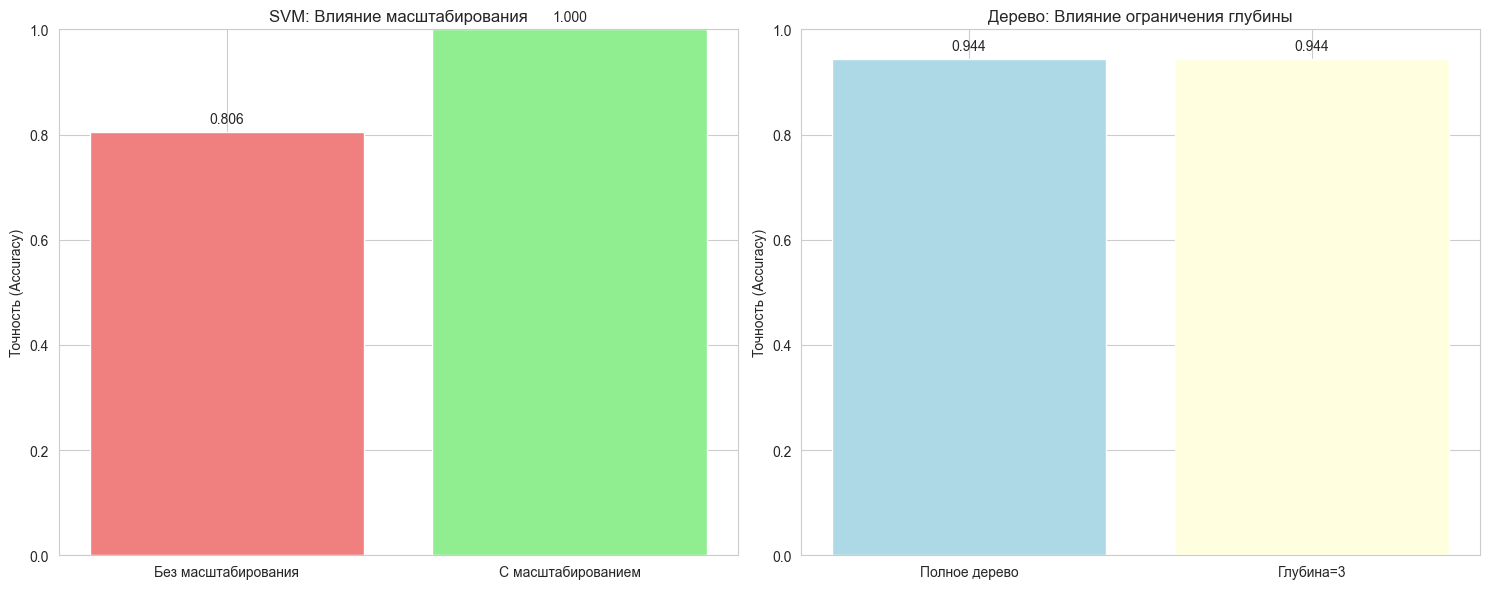

In [22]:
# Визуализация результатов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# SVM результаты
svm_results = [acc_no, acc_yes]
svm_labels = ['Без масштабирования', 'С масштабированием']
bars1 = ax1.bar(svm_labels, svm_results, color=['lightcoral', 'lightgreen'])
ax1.set_ylabel('Точность (Accuracy)')
ax1.set_title('SVM: Влияние масштабирования')
ax1.set_ylim(0, 1)
# Добавляем значения на столбцы
for bar, value in zip(bars1, svm_results):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom')

# Дерево результаты
tree_results = [acc_tree_full, acc_tree_limited]
tree_labels = ['Полное дерево', 'Глубина=3']
bars2 = ax2.bar(tree_labels, tree_results, color=['lightblue', 'lightyellow'])
ax2.set_ylabel('Точность (Accuracy)')
ax2.set_title('Дерево: Влияние ограничения глубины')
ax2.set_ylim(0, 1)
# Добавляем значения на столбцы
for bar, value in zip(bars2, tree_results):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Задача 3. Подбор гиперпараметров с GridSearchCV на наборе Wine

**Цель:** Найти лучшие гиперпараметры для каждой модели.

In [24]:
# Подготовка данных
print("=== ПОДГОТОВКА ДАННЫХ ДЛЯ GRIDSEARCH ===")

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование для k-NN и SVM
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Масштабированные данные подготовлены для k-NN и SVM")

=== ПОДГОТОВКА ДАННЫХ ДЛЯ GRIDSEARCH ===
Обучающая выборка: (142, 13)
Тестовая выборка: (36, 13)
Масштабированные данные подготовлены для k-NN и SVM


In [25]:
# 1. k-NN с подбором гиперпараметров
print("\n=== 1. k-NN: ПОДБОР ГИПЕРПАРАМЕТРОВ ===")

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 21)},
    cv=5, scoring='accuracy'
)
knn_grid.fit(X_train_s, y_train)

print("Лучший k-NN:", knn_grid.best_params_, "CV-точность:", round(knn_grid.best_score_, 4))


=== 1. k-NN: ПОДБОР ГИПЕРПАРАМЕТРОВ ===
Лучший k-NN: {'n_neighbors': 13} CV-точность: 0.9648


In [26]:
# 2. SVM с подбором гиперпараметров
print("\n=== 2. SVM: ПОДБОР ГИПЕРПАРАМЕТРОВ ===")

svm_grid = GridSearchCV(
    SVC(random_state=42),
    {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    },
    cv=5, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train_s, y_train)

print("Лучший SVM:", svm_grid.best_params_, "CV-точность:", round(svm_grid.best_score_, 4))


=== 2. SVM: ПОДБОР ГИПЕРПАРАМЕТРОВ ===
Лучший SVM: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'} CV-точность: 0.9788


In [27]:
# 3. Дерево решений с подбором гиперпараметров
print("\n=== 3. ДЕРЕВО РЕШЕНИЙ: ПОДБОР ГИПЕРПАРАМЕТРОВ ===")

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        'max_depth': [2, 3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    cv=5, scoring='accuracy'
)
tree_grid.fit(X_train, y_train)  # без масштабирования!

print("Лучшее дерево:", tree_grid.best_params_, "CV-точность:", round(tree_grid.best_score_, 4))


=== 3. ДЕРЕВО РЕШЕНИЙ: ПОДБОР ГИПЕРПАРАМЕТРОВ ===
Лучшее дерево: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2} CV-точность: 0.9224



=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ K-NN ===


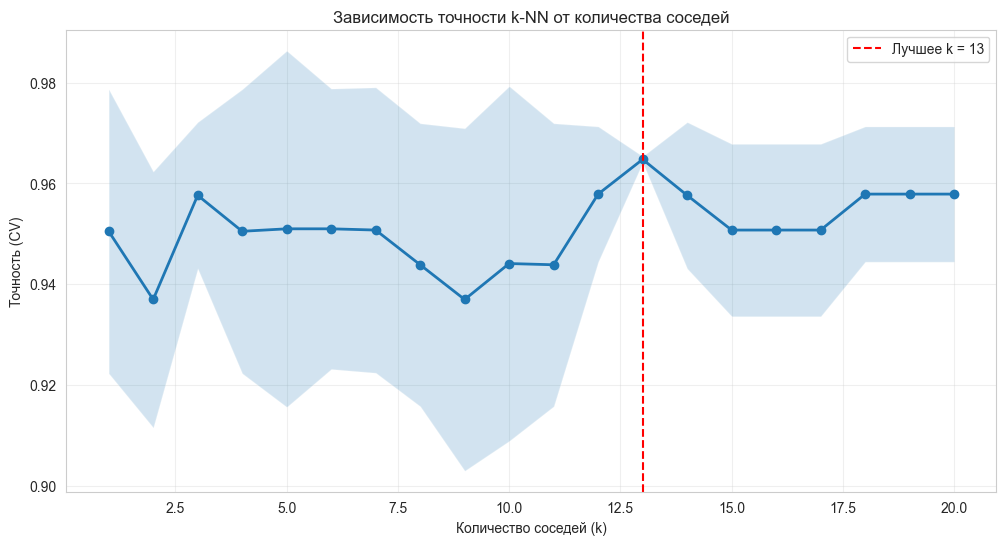

In [28]:
# Визуализация результатов GridSearch для k-NN
print("\n=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ K-NN ===")

knn_results = pd.DataFrame(knn_grid.cv_results_)

plt.figure(figsize=(12, 6))
plt.plot(knn_results['param_n_neighbors'], knn_results['mean_test_score'], marker='o', linewidth=2)
plt.fill_between(knn_results['param_n_neighbors'], 
                 knn_results['mean_test_score'] - knn_results['std_test_score'],
                 knn_results['mean_test_score'] + knn_results['std_test_score'],
                 alpha=0.2)
plt.axvline(knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Лучшее k = {knn_grid.best_params_["n_neighbors"]}')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность (CV)')
plt.title('Зависимость точности k-NN от количества соседей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


=== АНАЛИЗ РЕЗУЛЬТАТОВ SVM ===
Лучшее ядро: rbf
Лучшие параметры SVM: C=1, gamma=0.01


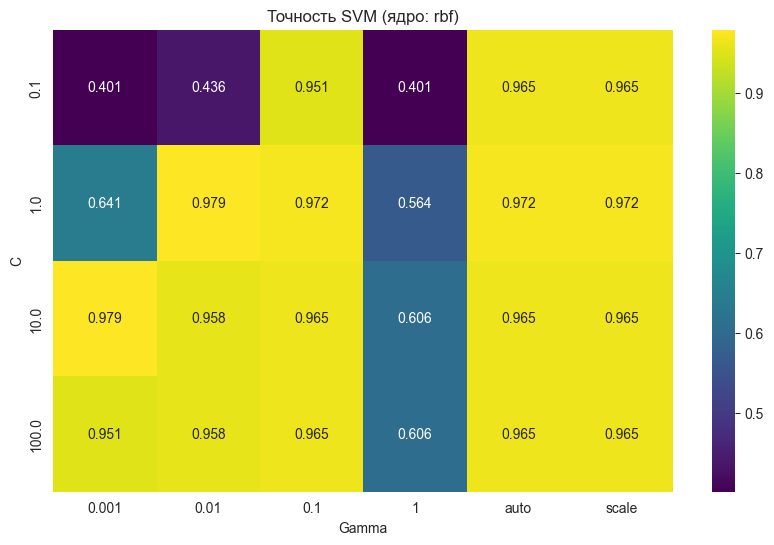

In [29]:
# Визуализация результатов GridSearch для SVM
print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ SVM ===")

svm_results = pd.DataFrame(svm_grid.cv_results_)

# Фильтруем результаты для лучшего ядра
best_kernel = svm_grid.best_params_['kernel']
best_kernel_results = svm_results[svm_results['param_kernel'] == best_kernel]

print(f"Лучшее ядро: {best_kernel}")
print(f"Лучшие параметры SVM: C={svm_grid.best_params_['C']}, gamma={svm_grid.best_params_['gamma']}")

# Создаем тепловую карту для SVM (для лучшего ядра)
if best_kernel == 'rbf':
    # Создаем pivot таблицу для тепловой карты
    heatmap_data = best_kernel_results.pivot_table(
        values='mean_test_score',
        index='param_C',
        columns='param_gamma'
    )
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='viridis')
    plt.title(f'Точность SVM (ядро: {best_kernel})')
    plt.xlabel('Gamma')
    plt.ylabel('C')
    plt.show()


=== АНАЛИЗ РЕЗУЛЬТАТОВ ДЕРЕВА РЕШЕНИЙ ===
Лучшая глубина: 3
Лучшие параметры дерева: min_samples_split=2, min_samples_leaf=1


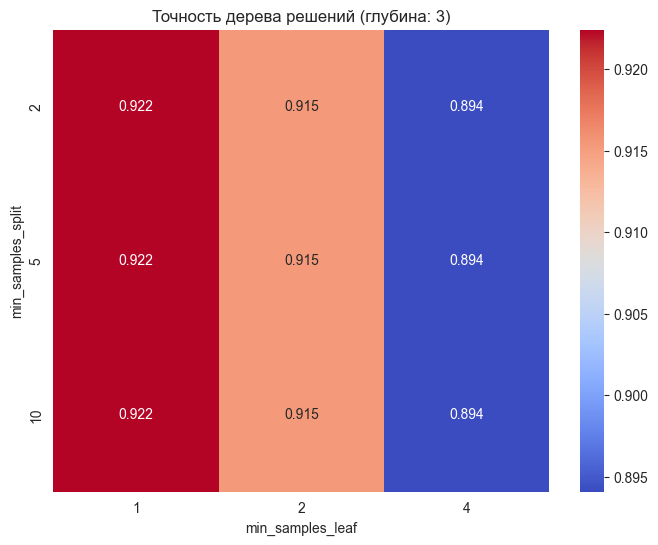

In [30]:
# Визуализация результатов GridSearch для дерева решений
print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ДЕРЕВА РЕШЕНИЙ ===")

tree_results = pd.DataFrame(tree_grid.cv_results_)

# Фильтруем результаты для лучшей глубины
best_depth = tree_grid.best_params_['max_depth']
best_depth_results = tree_results[tree_results['param_max_depth'] == best_depth]

print(f"Лучшая глубина: {best_depth}")
print(f"Лучшие параметры дерева: min_samples_split={tree_grid.best_params_['min_samples_split']}, "
      f"min_samples_leaf={tree_grid.best_params_['min_samples_leaf']}")

# Создаем тепловую карту для дерева (для лучшей глубины)
if best_depth is not None:
    heatmap_data_tree = best_depth_results.pivot_table(
        values='mean_test_score',
        index='param_min_samples_split',
        columns='param_min_samples_leaf'
    )
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data_tree, annot=True, fmt='.3f', cmap='coolwarm')
    plt.title(f'Точность дерева решений (глубина: {best_depth})')
    plt.xlabel('min_samples_leaf')
    plt.ylabel('min_samples_split')
    plt.show()

In [31]:
# Оценка лучших моделей на тестовой выборке
print("\n=== ОЦЕНКА ЛУЧШИХ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ ===")

# Лучшие модели
best_knn = knn_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_tree = tree_grid.best_estimator_

# Предсказания
knn_test_pred = best_knn.predict(X_test_s)
svm_test_pred = best_svm.predict(X_test_s)
tree_test_pred = best_tree.predict(X_test)

# Точность на тесте
knn_test_acc = accuracy_score(y_test, knn_test_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)
tree_test_acc = accuracy_score(y_test, tree_test_pred)

print(f"k-NN тестовая точность:  {knn_test_acc:.4f}")
print(f"SVM тестовая точность:   {svm_test_acc:.4f}")
print(f"Tree тестовая точность:  {tree_test_acc:.4f}")


=== ОЦЕНКА ЛУЧШИХ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ ===
k-NN тестовая точность:  0.9722
SVM тестовая точность:   1.0000
Tree тестовая точность:  0.9444


In [32]:
# Сравнительная таблица результатов
print("\n=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===")

results_comparison = pd.DataFrame({
    'Модель': ['k-NN', 'SVM', 'Decision Tree'],
    'Лучшие параметры': [
        str(knn_grid.best_params_),
        str(svm_grid.best_params_),
        str(tree_grid.best_params_)
    ],
    'CV точность': [
        round(knn_grid.best_score_, 4),
        round(svm_grid.best_score_, 4),
        round(tree_grid.best_score_, 4)
    ],
    'Тестовая точность': [
        round(knn_test_acc, 4),
        round(svm_test_acc, 4),
        round(tree_test_acc, 4)
    ]
})

print(results_comparison.to_string(index=False))


=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===
       Модель                                                Лучшие параметры  CV точность  Тестовая точность
         k-NN                                             {'n_neighbors': 13}       0.9648             0.9722
          SVM                        {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}       0.9788             1.0000
Decision Tree {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}       0.9224             0.9444


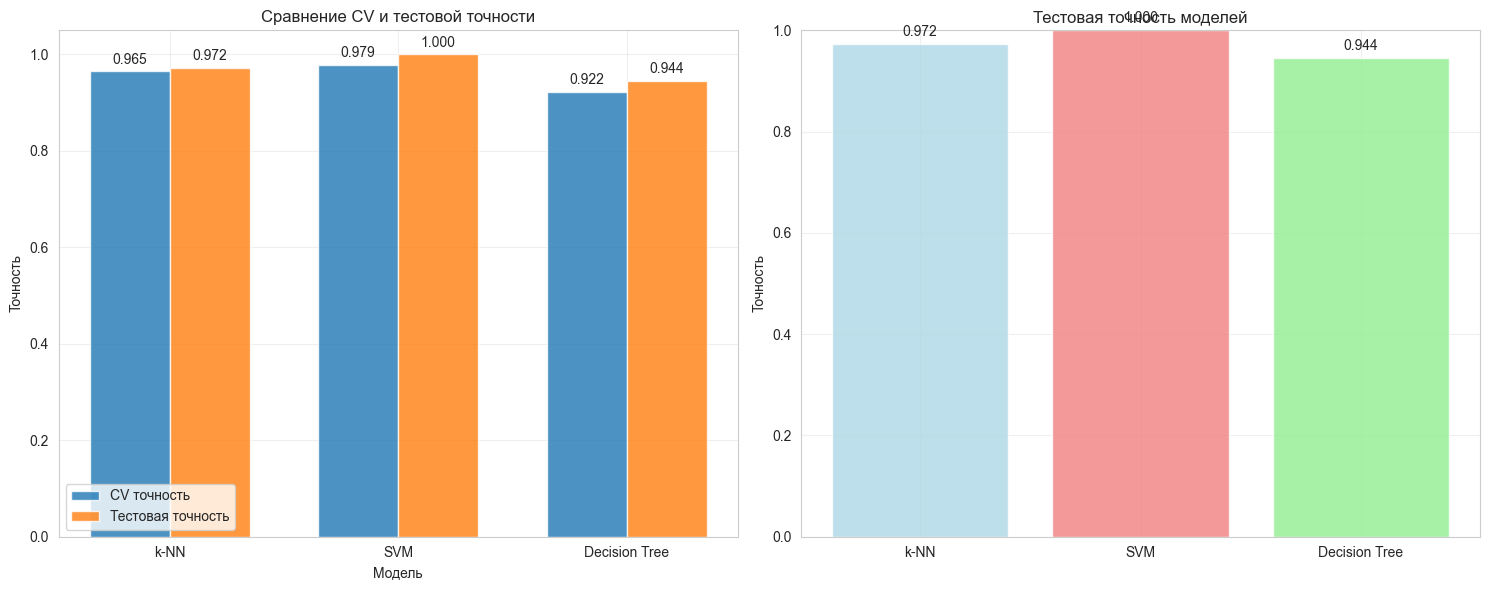

In [33]:
# Визуализация сравнения моделей
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# CV точность
models = ['k-NN', 'SVM', 'Decision Tree']
cv_scores = [knn_grid.best_score_, svm_grid.best_score_, tree_grid.best_score_]
test_scores = [knn_test_acc, svm_test_acc, tree_test_acc]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, cv_scores, width, label='CV точность', alpha=0.8)
bars2 = ax1.bar(x + width/2, test_scores, width, label='Тестовая точность', alpha=0.8)

ax1.set_xlabel('Модель')
ax1.set_ylabel('Точность')
ax1.set_title('Сравнение CV и тестовой точности')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')

# Сравнение тестовой точности
colors = ['lightblue', 'lightcoral', 'lightgreen']
bars = ax2.bar(models, test_scores, color=colors, alpha=0.8)
ax2.set_ylabel('Точность')
ax2.set_title('Тестовая точность моделей')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Задача 4. Сравнение трёх оптимизированных моделей

**Цель:** Сравнить модели по **точности**, **скорости обучения** и **интерпретируемости**.

In [34]:
# Используем лучшие модели из предыдущей задачи
print("=== ЗАГРУЗКА ЛУЧШИХ МОДЕЛЕЙ ИЗ ЗАДАЧИ 3 ===")

# Лучшие модели (предполагаем, что они уже обучены в предыдущих ячейках)
best_knn = knn_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_tree = tree_grid.best_estimator_

print("Лучшие модели загружены:")
print(f"k-NN: {knn_grid.best_params_}")
print(f"SVM: {svm_grid.best_params_}")
print(f"Decision Tree: {tree_grid.best_params_}")

=== ЗАГРУЗКА ЛУЧШИХ МОДЕЛЕЙ ИЗ ЗАДАЧИ 3 ===
Лучшие модели загружены:
k-NN: {'n_neighbors': 13}
SVM: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Decision Tree: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [35]:
# Сравнение моделей по точности, скорости обучения и интерпретируемости
print("=== СРАВНЕНИЕ ОПТИМИЗИРОВАННЫХ МОДЕЛЕЙ ===")

# Данные для разных моделей
X_test_knn_svm = X_test_s  # масштабированные
X_test_tree = X_test       # оригинальные

models_final = {
    "k-NN": (best_knn, X_test_knn_svm),
    "SVM": (best_svm, X_test_knn_svm),
    "Decision Tree": (best_tree, X_test_tree)
}

comparison = []

for name, (model, X_test_m) in models_final.items():
    # Время обучения (повторное обучение для замера)
    X_train_m = X_train_s if name in ["k-NN", "SVM"] else X_train
    
    start = time.time()
    model.fit(X_train_m, y_train)
    train_time = time.time() - start
    
    # Точность на тесте
    test_acc = model.score(X_test_m, y_test)
    
    comparison.append({
        "Модель": name,
        "Точность (тест)": round(test_acc, 4),
        "Время обучения (сек)": round(train_time, 4)
    })

# Вывод таблицы
df_comp = pd.DataFrame(comparison)
print("Сравнение моделей:")
print(df_comp.to_string(index=False))

=== СРАВНЕНИЕ ОПТИМИЗИРОВАННЫХ МОДЕЛЕЙ ===
Сравнение моделей:
       Модель  Точность (тест)  Время обучения (сек)
         k-NN           0.9722                0.0019
          SVM           1.0000                0.0020
Decision Tree           0.9444                0.0022


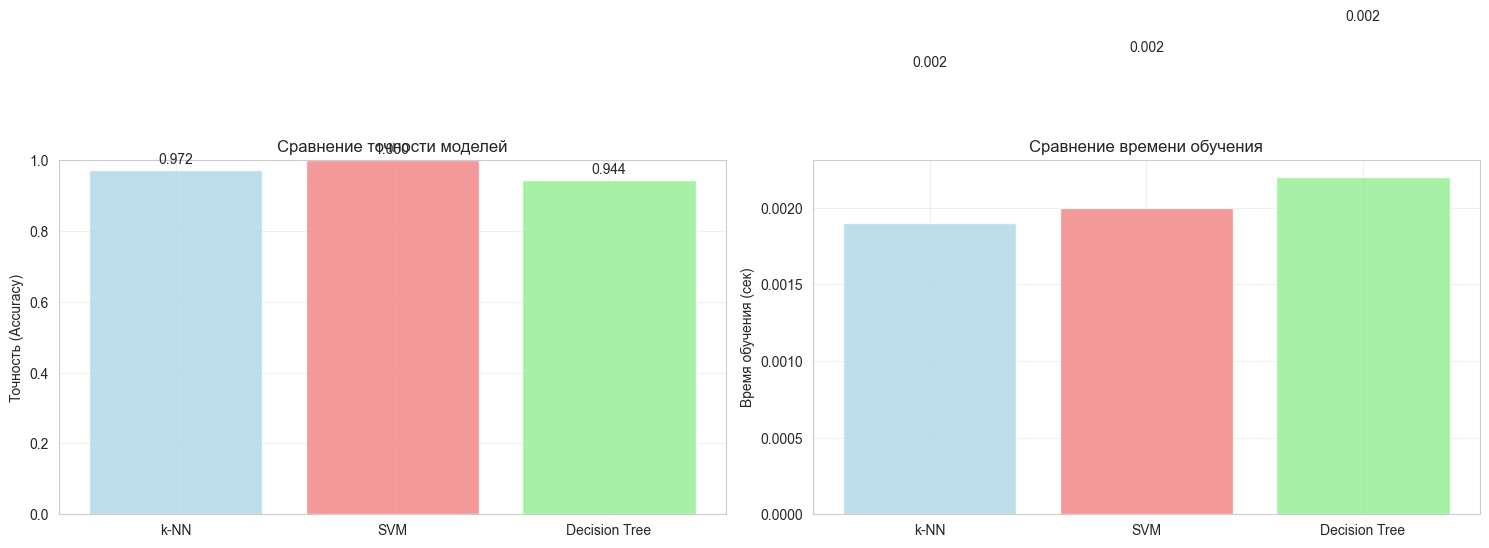

In [36]:
# Визуализация сравнения точности и времени
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Точность
models = df_comp['Модель']
accuracies = df_comp['Точность (тест)']
times = df_comp['Время обучения (сек)']

bars1 = ax1.bar(models, accuracies, color=['lightblue', 'lightcoral', 'lightgreen'], alpha=0.8)
ax1.set_ylabel('Точность (Accuracy)')
ax1.set_title('Сравнение точности моделей')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

# Время обучения
bars2 = ax2.bar(models, times, color=['lightblue', 'lightcoral', 'lightgreen'], alpha=0.8)
ax2.set_ylabel('Время обучения (сек)')
ax2.set_title('Сравнение времени обучения')
ax2.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [37]:
# Сравнительный анализ всех характеристик
print("\n=== КОМПЛЕКСНОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===")

# Добавляем дополнительные метрики
complex_comparison = []

for name, (model, X_test_m) in models_final.items():
    X_train_m = X_train_s if name in ["k-NN", "SVM"] else X_train
    
    # Время предсказания
    start_pred = time.time()
    _ = model.predict(X_test_m)
    pred_time = time.time() - start_pred
    
    # Точность на обучении (для анализа переобучения)
    train_acc = model.score(X_train_m, y_train)
    test_acc = model.score(X_test_m, y_test)
    
    # Оценка интерпретируемости
    interpretability = {
        "k-NN": "Низкая",
        "SVM": "Средняя", 
        "Decision Tree": "Высокая"
    }[name]
    
    complex_comparison.append({
        "Модель": name,
        "Точность (train)": round(train_acc, 4),
        "Точность (test)": round(test_acc, 4),
        "Разница (train-test)": round(train_acc - test_acc, 4),
        "Время обучения (сек)": round(train_time, 4),
        "Время предсказания (сек)": round(pred_time, 6),
        "Интерпретируемость": interpretability
    })

df_complex = pd.DataFrame(complex_comparison)
print("Комплексное сравнение моделей:")
print(df_complex.to_string(index=False))


=== КОМПЛЕКСНОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===
Комплексное сравнение моделей:
       Модель  Точность (train)  Точность (test)  Разница (train-test)  Время обучения (сек)  Время предсказания (сек) Интерпретируемость
         k-NN            0.9648           0.9722               -0.0074                0.0022                  0.004375             Низкая
          SVM            0.9789           1.0000               -0.0211                0.0022                  0.000000            Средняя
Decision Tree            0.9930           0.9444                0.0485                0.0022                  0.001046            Высокая


### Вопросы
1. Какая модель показала **наивысшую точность**?
2. Какая модель обучалась **быстрее всего**?
3. Какая модель **наиболее интерпретируема**? Почему это важно в реальных задачах (медицина, финансы)?
4. Есть ли компромисс между точностью и интерпретируемостью?

In [38]:
# Ответы на вопросы
print("="*50)
print("ОТВЕТЫ НА ВОПРОСЫ")
print("="*50)

# Вопрос 1
best_model = df_comp.loc[df_comp['Точность (тест)'].idxmax()]
print(f"1. 🎯 Наивысшая точность: {best_model['Модель']} ({best_model['Точность (тест)']:.4f})")

# Вопрос 2  
fastest_model = df_comp.loc[df_comp['Время обучения (сек)'].idxmin()]
print(f"2. ⚡ Самая быстрая: {fastest_model['Модель']} ({fastest_model['Время обучения (сек)']:.4f} сек)")

# Вопрос 3
print(f"3. 🔍 Наиболее интерпретируема: Decision Tree")
print("   Важно в медицине/финансах: прозрачность решений, объяснимость, юридическая ответственность")

# Вопрос 4
print(f"4. ⚖️ Компромисс точность/интерпретируемость: ДА")
print(f"   • SVM: высокая точность ({df_comp[df_comp['Модель']=='SVM']['Точность (тест)'].values[0]:.4f}), низкая интерпретируемость")
print(f"   • Tree: средняя точность ({df_comp[df_comp['Модель']=='Decision Tree']['Точность (тест)'].values[0]:.4f}), высокая интерпретируемость")

print("\n🏆 ВЫВОД: Выбор модели зависит от задачи - точность vs объяснимость")

ОТВЕТЫ НА ВОПРОСЫ
1. 🎯 Наивысшая точность: SVM (1.0000)
2. ⚡ Самая быстрая: k-NN (0.0019 сек)
3. 🔍 Наиболее интерпретируема: Decision Tree
   Важно в медицине/финансах: прозрачность решений, объяснимость, юридическая ответственность
4. ⚖️ Компромисс точность/интерпретируемость: ДА
   • SVM: высокая точность (1.0000), низкая интерпретируемость
   • Tree: средняя точность (0.9444), высокая интерпретируемость

🏆 ВЫВОД: Выбор модели зависит от задачи - точность vs объяснимость
